# (노트) 인자분석 - FIFA 축구선수 능력치 
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [응용통계]

### About this doc 

`-` 인자분석 예제: FIFA 축구선수 능력치 

`-` 데이터 출처: https://www.kaggle.com/bryanb/fifa-player-stats-database?select=FIFA21_official_data.csv


### Data

`-` 아래의 자료는 유명한 비디오 게임이 제공하는 축구선수들의 능력치에 대한 자료이다. 

In [1]:
library(tidyverse)
fifa_dat=read_csv('2021-07-01-fifa.csv')

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.0.6     ✔ dplyr   1.0.6
✔ tidyr   1.1.2     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


── Column specification ────────────────────────────────────────────────────────
cols(
  .default = col_double()
)
ℹ Use `spec()` for the full column specifications.




In [2]:
head(fifa_dat)

Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,⋯,Vision,Penalties,Composure,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
80,92,84,83,90,84,86,82,77,84,⋯,84,83,85,45,38,27,25,31,33,37
94,82,55,94,82,88,85,83,93,92,⋯,94,84,91,65,53,15,13,5,10,13
87,77,58,88,86,85,86,87,87,88,⋯,90,91,86,67,55,12,14,15,8,14
83,88,83,84,87,87,86,85,82,89,⋯,85,86,89,54,49,14,8,14,13,14
87,66,57,81,68,87,88,75,78,87,⋯,82,76,87,82,79,8,14,13,13,14
89,65,67,83,67,82,87,79,87,82,⋯,76,81,78,81,79,13,8,12,11,14


`-` 데이터는 캐글의 FIFA21 OFFICIAL DATASET 을 활용하였다. 
- 출처: https://www.kaggle.com/bryanb/fifa-player-stats-database?select=FIFA21_official_data.csv 

`-` 문제의 분석을 위하여 선수의 능력치와 관련없는 일부변수는 제외하였으며 (이름, 얼굴사진 등) 정리된 자료는 아래에서 다운받을 수 있다. 
- https://github.com/miruetoto/yechan/blob/master/_notebooks/2021-07-01-fifa.csv

`-` 자료구조 
- $n$: 16821 player 
- $p$: 33 variable 

`-` 각 변수들은 축구선수들의 능력치와 관련되어 있으며 구체적인 목록은 아래와 같다. 

In [3]:
print(names(fifa_dat))

 [1] "Crossing"        "Finishing"       "HeadingAccuracy" "ShortPassing"   
 [5] "Volleys"         "Dribbling"       "Curve"           "FKAccuracy"     
 [9] "LongPassing"     "BallControl"     "Acceleration"    "SprintSpeed"    
[13] "Agility"         "Reactions"       "Balance"         "ShotPower"      
[17] "Jumping"         "Stamina"         "Strength"        "LongShots"      
[21] "Aggression"      "Interceptions"   "Positioning"     "Vision"         
[25] "Penalties"       "Composure"       "StandingTackle"  "SlidingTackle"  
[29] "GKDiving"        "GKHandling"      "GKKicking"       "GKPositioning"  
[33] "GKReflexes"     


### 고유값 

In [7]:
library(psych)
fifa_factor=principal(fifa_dat,rotate='none')

In [8]:
fifa_factor$values

[1] 17.87966149  4.54274240  2.94590728  1.79041155  1.36780887  0.60224284
 [7]  0.44224002  0.33838567  0.31283176  0.28427022  0.25838792  0.23860340
[13]  0.20710617  0.19496595  0.18922822  0.17197376  0.15497700  0.13182625
[19]  0.12808383  0.11847152  0.10326586  0.09009330  0.07669736  0.06474389
[25]  0.06193828  0.06017035  0.05631684  0.03771976  0.03423692  0.03235278
[31]  0.03188949  0.02812511  0.02232395

`-` 5번째 인자까지 고유값이 1이상인 것을 알 수 있다. 

### 스크리 그림

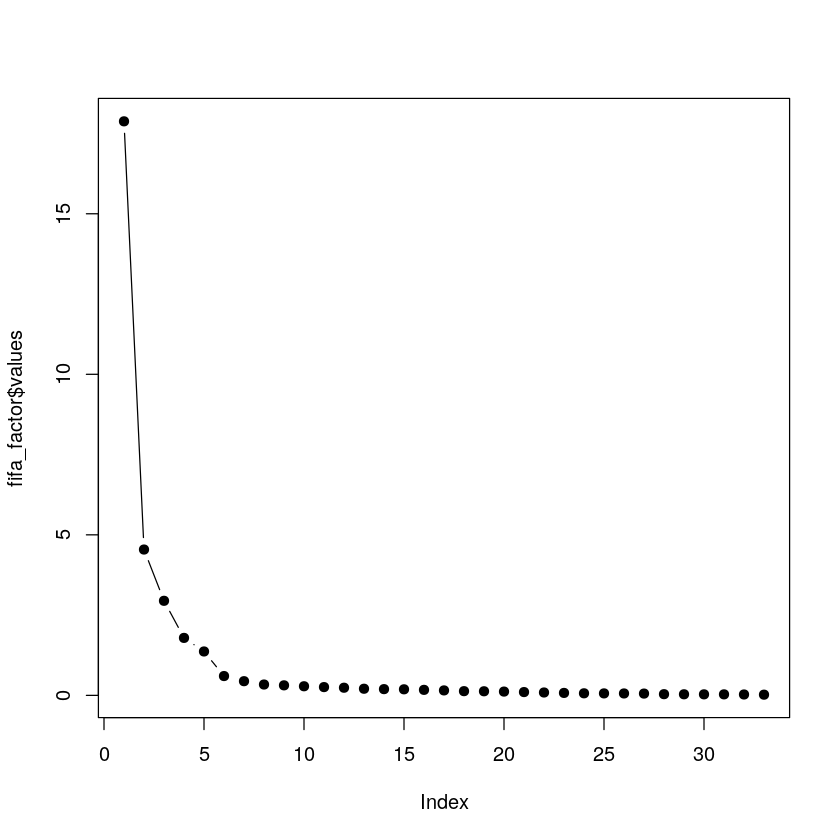

In [9]:
plot(fifa_factor$values,type='b',pch=19)

`-` 유효한 인자수는 5개정도로 볼 수 있다. 

### 인자회전

`-` 본 예제에서는 직교회전의 varimax을 사용하였다. 

In [13]:
fifa_varimax = principal(fifa_dat,nfactors=5,rotate="varimax")
fifa_varimax

Principal Components Analysis
Call: principal(r = fifa_dat, nfactors = 5, rotate = "varimax")
Standardized loadings (pattern matrix) based upon correlation matrix
                  RC1   RC3   RC2   RC4   RC5   h2    u2 com
Crossing         0.64  0.31  0.35  0.44 -0.08 0.83 0.170 3.0
Finishing        0.79  0.42 -0.22  0.26  0.08 0.92 0.078 2.0
HeadingAccuracy  0.31  0.64  0.33 -0.08  0.50 0.87 0.126 3.0
ShortPassing     0.68  0.38  0.48  0.24  0.07 0.89 0.106 2.8
Volleys          0.82  0.39 -0.11  0.21  0.09 0.88 0.118 1.7
Dribbling        0.69  0.47  0.17  0.45  0.01 0.93 0.074 2.7
Curve            0.79  0.29  0.18  0.32 -0.08 0.85 0.147 1.8
FKAccuracy       0.79  0.25  0.20  0.20 -0.14 0.78 0.217 1.6
LongPassing      0.64  0.19  0.60  0.18 -0.04 0.84 0.156 2.3
BallControl      0.70  0.49  0.29  0.34  0.08 0.93 0.073 2.7
Acceleration     0.29  0.33  0.00  0.83  0.09 0.89 0.107 1.6
SprintSpeed      0.25  0.36  0.00  0.78  0.18 0.84 0.159 1.8
Agility          0.46  0.19  0.04  0.79 -0.0

#### h2, u2

`-` h2는 각 변수들이 유의한 다섯개의 인자 RC1,...,RC5에 의하여 설명되어지는 부분의 비율인 공통성을 나타내며, 위의 인자부하값을 이용하여 다음과 같이 구해진다. 

- Crossing : $0.83=0.64^2+0.31^2+0.35^2+0.44^2+(-0.08)^2$
- Finishing : $0.92=0.79^2+0.42^2+(-0.22)^2+0.26^2+(0.08)^2$
- ... 

`-` 공통성이 많은 변수중에서 서로 연관이 있는 일부 변수들을 선택하기 위해서 인자분석을 실시하는 경우 변수선택의 기준으로 이용할 수 있다. 예를들어 위의 예제 Jumping의 경우 공통성을 나타내는 지표인 h2가 0.69으로 다른 변수들보다 상대적으로 낮은데 이는 Jumping이 다른 변수들과 공통점이 별로 없는 것으로 판단 할 수 있다. 

`-` u2=1-h2는 고유분산을 의미한다. 

#### SS lodings

`-` SS lodings은 각 인자에 의해 설명되는 분산의 양을 나타낸다. 이는 인자 부하값의 제곱의 합으로 다음과 같이 구해진다. 
- RC1: $10.24 = 0.64^2+0.79^2+ \dots + (-0.27)^2$ 
- RC3: $6.69 = 0.31^2+0.42^2+ \dots + (-0.86)^2$
- ... 

#### Proportion Var, Cumulative Var

`-` Proportion Var와 Cumulative Var는 각 각 인자가 설명하는 총분산의 비율과 그 누적값을 의미한다. 

`-` RC1이 총 분산의 31%, RC3이 총 분산의 20%를 설명한다. 

`-` RC1, RC3, RC2, RC4 에 의하여 설명되는 변동은 총 변동의 80%이다. 

#### RC1, RC3, RC2, RC4, RC5

`-` RC1은 Finishing, Volleys, Curve, FKAccuracy, BallControl, ShotPower, LongShots, Positioning, Vision, Penalties, Composure 가 높은 값을 가진다. 따라서 이 인자는 스트라이커 혹은 공격형 미드필터가 필요로 하는 능력치로 해석할 수 있다. 

In [14]:
print(fifa_varimax$loadings[,1])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
    0.637414357     0.789351141     0.314495690     0.679312050     0.817184293 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
    0.692339194     0.793309064     0.787869456     0.640837523     0.699742170 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
    0.285434185     0.254968288     0.459628451     0.627043368     0.345772217 
      ShotPower         Jumping         Stamina        Strength       LongShots 
    0.864972507    -0.027310685     0.357176146     0.094780306     0.846494679 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    0.273190265     0.050081960     0.752984594     0.853045973     0.756603398 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
    0.748901773     0.007312332    -0.037213362    -0.273567738    -0.273606418 
      GKKicking   GKPosition

`-` RC3은 Interceptions, StandingTackle, SlidingTackle 가 높은 적재값을 가진다. 따라서 이는 수비수가 필요로 하는 능력치로 해석할 수 있다. 

In [15]:
print(fifa_varimax$loadings[,3])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
   0.3545081595   -0.2161529958    0.3307642513    0.4752724169   -0.1112193429 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
   0.1705703476    0.1751259500    0.2002665071    0.6026588521    0.2856359932 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
   0.0032365752   -0.0001120553    0.0407499359    0.3273344278    0.1058226056 
      ShotPower         Jumping         Stamina        Strength       LongShots 
  -0.0576638663    0.1731688062    0.4429347162    0.2117825446    0.0153585077 
     Aggression   Interceptions     Positioning          Vision       Penalties 
   0.6571972702    0.9323630320   -0.0030276636    0.1552658643   -0.1007701795 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
   0.3409204839    0.9333718619    0.9343377299   -0.2863346939   -0.2854453599 
      GKKicking   GKPosition

`-` RC2는 GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes 에서 큰 음의 값을 가진다. 따라서 이는 골키퍼와 필드플레이어를 구분하는 인자로 해석할 수 있다. 

In [16]:
print(fifa_varimax$loadings[,2])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
     0.31214662      0.41933383      0.64246521      0.37776058      0.38819034 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
     0.46840877      0.28684346      0.24859071      0.19411924      0.48552810 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
     0.32707849      0.36363065      0.18845608     -0.32485924      0.19371315 
      ShotPower         Jumping         Stamina        Strength       LongShots 
     0.05637016      0.01232201      0.38219661      0.12138102      0.35085321 
     Aggression   Interceptions     Positioning          Vision       Penalties 
     0.33640174      0.19011315      0.43766528     -0.01085578      0.45721170 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
     0.04806416      0.26173005      0.24704362     -0.85919118     -0.85834341 
      GKKicking   GKPosition

`-` RC4는 Acceleration, SprintSpeed, Agility, Balance에서 높은 값을 가지므로 이는 민첩성과 연관된 인자로 해석할 수 있다. 

In [17]:
print(fifa_varimax$loadings[,4])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
     0.44057834      0.26335492     -0.08163892      0.24192353      0.20853217 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
     0.44533963      0.32323559      0.20349375      0.17510236      0.33754539 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
     0.83479909      0.78242186      0.78551196      0.02111821      0.76059085 
      ShotPower         Jumping         Stamina        Strength       LongShots 
     0.03130795      0.23549487      0.40600573     -0.45464984      0.22903278 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    -0.02067596      0.01054005      0.35901878      0.24666333      0.14701104 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
     0.09322065      0.02008380      0.03431326     -0.26305565     -0.26354954 
      GKKicking   GKPosition

`-` RC5는 Jumping, Strength 에서 높은 값을 가지므로 신체능력과 연관된 인자로 해석할 수 있다. 



In [18]:
print(fifa_varimax$loadings[,5])

       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
   -0.082976003     0.080839801     0.495947178     0.070290604     0.089382762 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
    0.006070171    -0.077326337    -0.137298742    -0.038434013     0.080584043 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
    0.090098167     0.177523057    -0.018781684     0.422364652    -0.178574515 
      ShotPower         Jumping         Stamina        Strength       LongShots 
    0.182561678     0.778857141     0.320509049     0.707282496     0.055360153 
     Aggression   Interceptions     Positioning          Vision       Penalties 
    0.405419727     0.158884237     0.076117981    -0.073452295     0.098902412 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
    0.293462931     0.109464396     0.095097385    -0.027687606    -0.028919699 
      GKKicking   GKPosition

`-` 아래는 이러한 해석을 시각화한 것이다. 

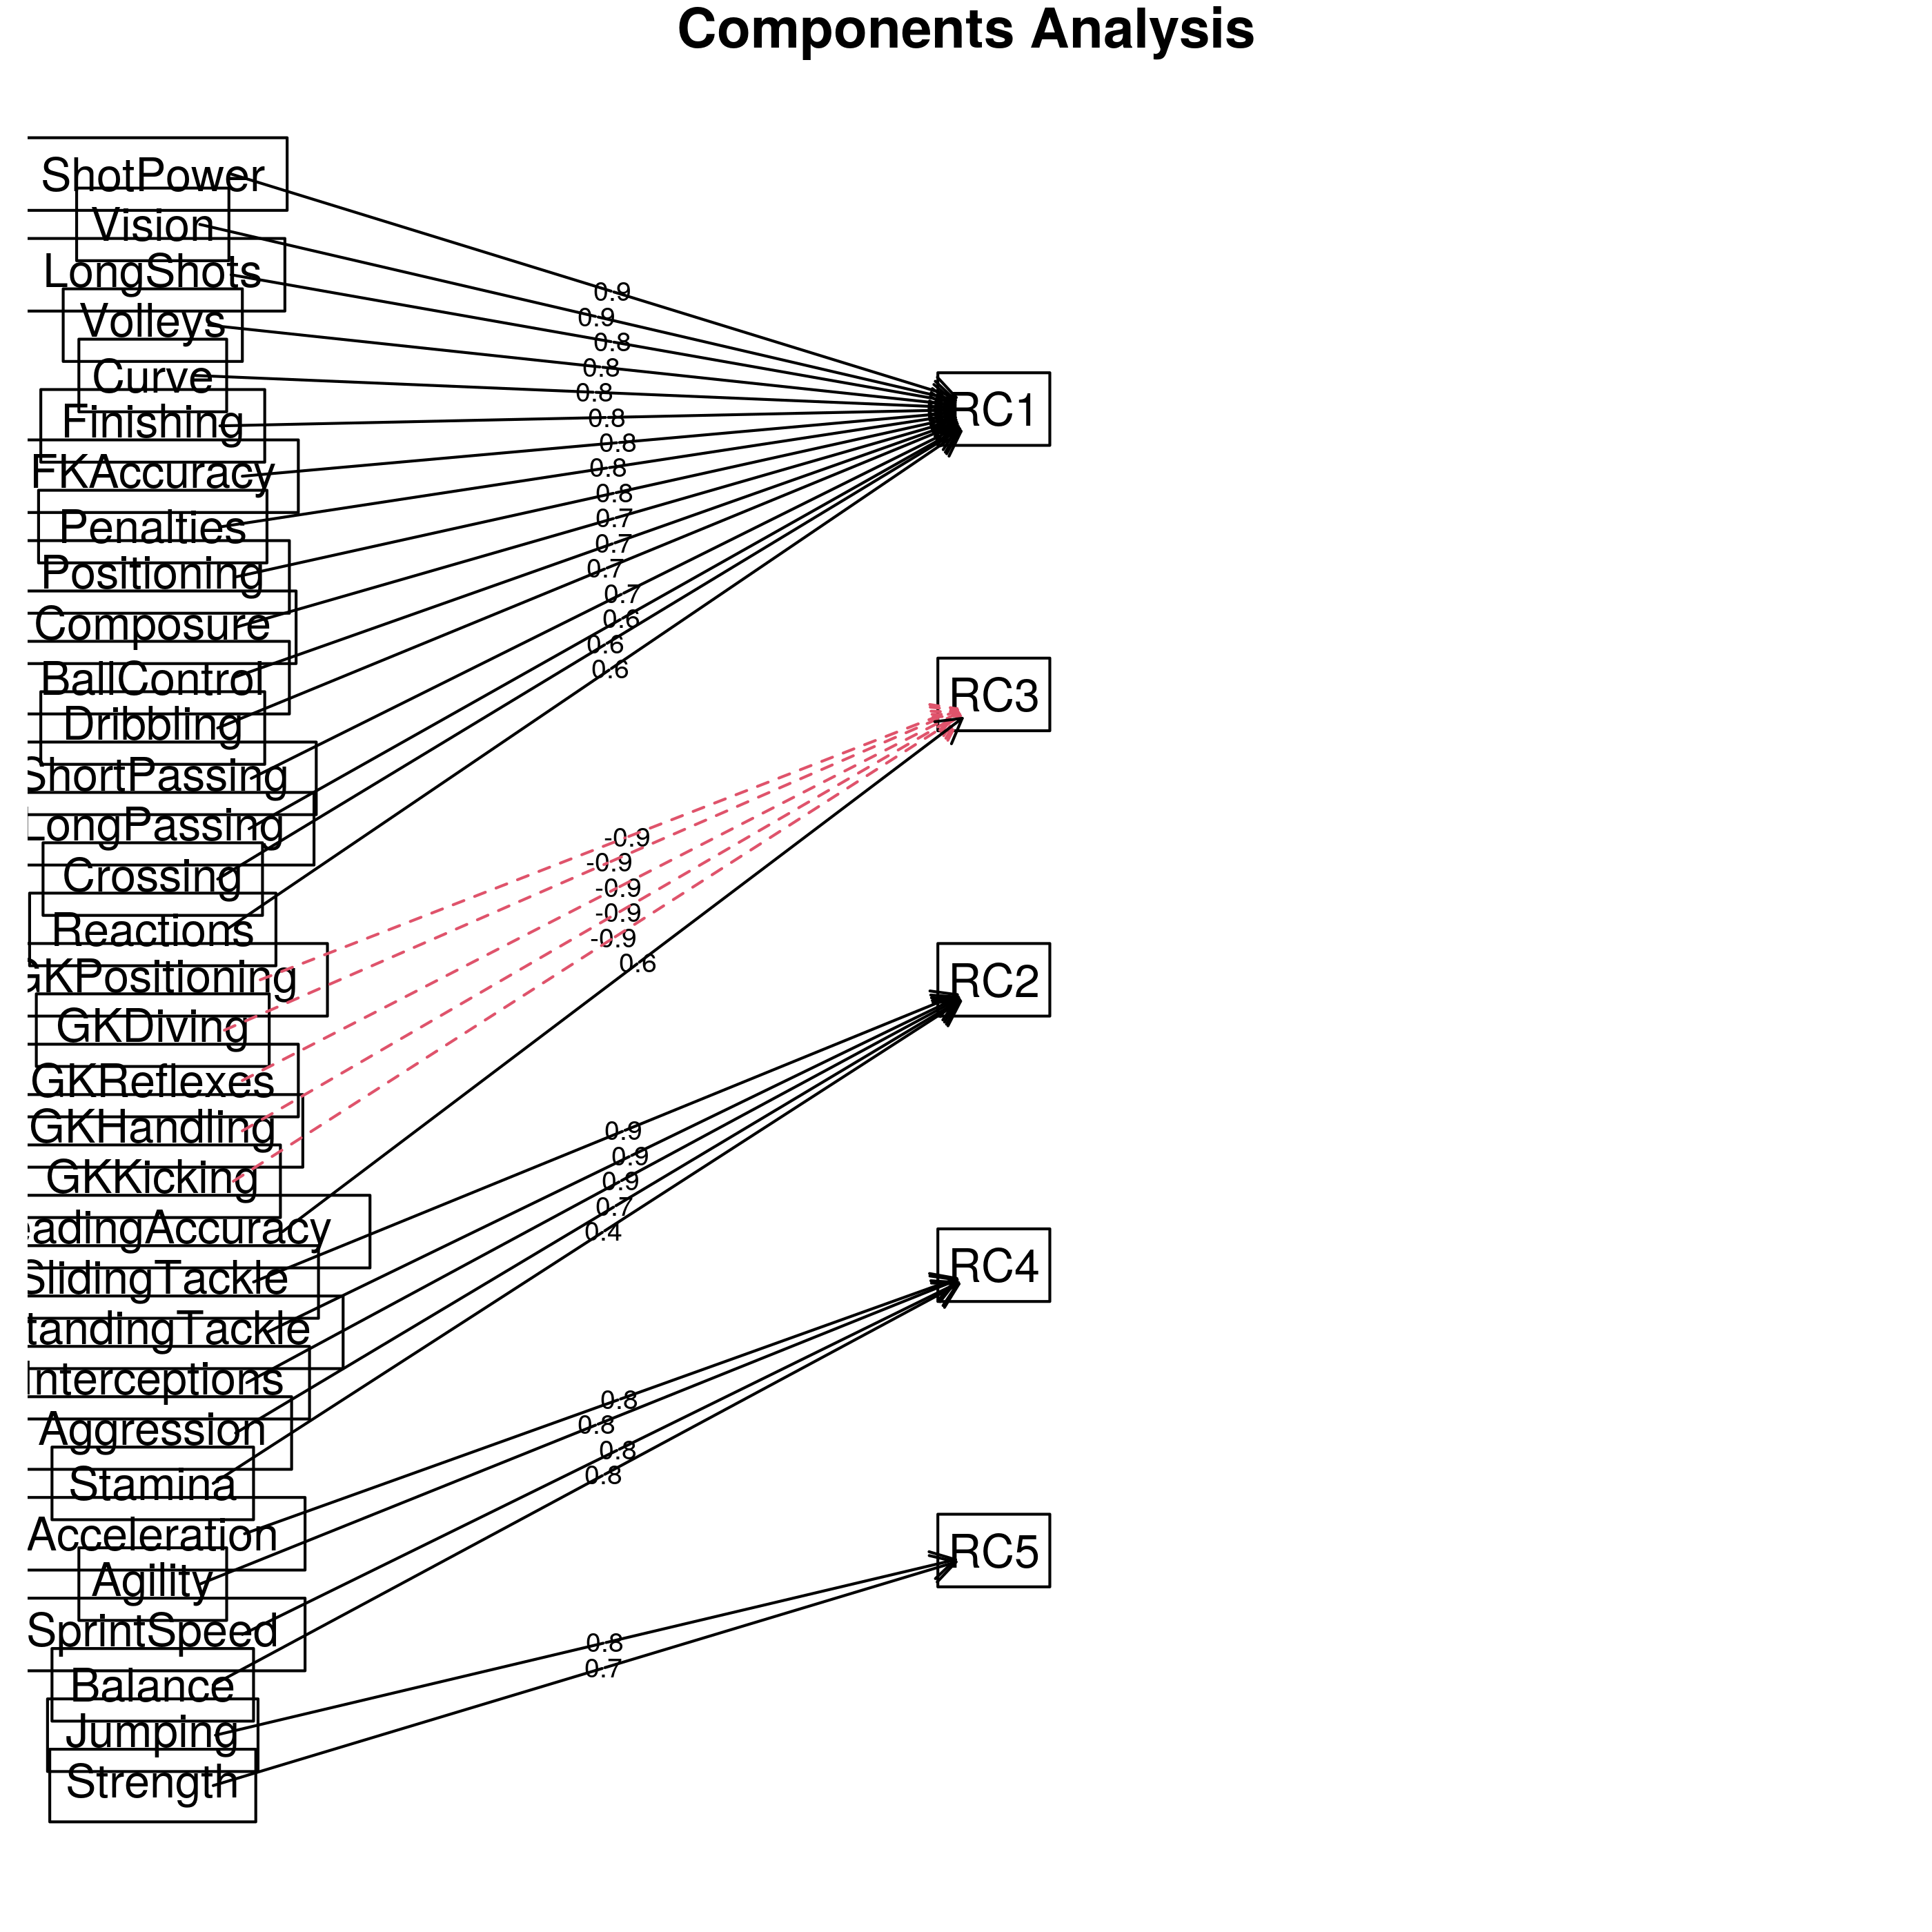

In [19]:
options(repr.plot.res=400)
fa.diagram(fifa_varimax)

### 행렬도 

`-` 아래는 Varimax를 이용하여 나타낸 행렬도이다. 

`-` RC3은 필드플레이어와 골키퍼를 구분하고 RC2는 수비형선수와 공격형선수를 구분하는 요인으로 해석할 수 있음을 알 수 있다. 

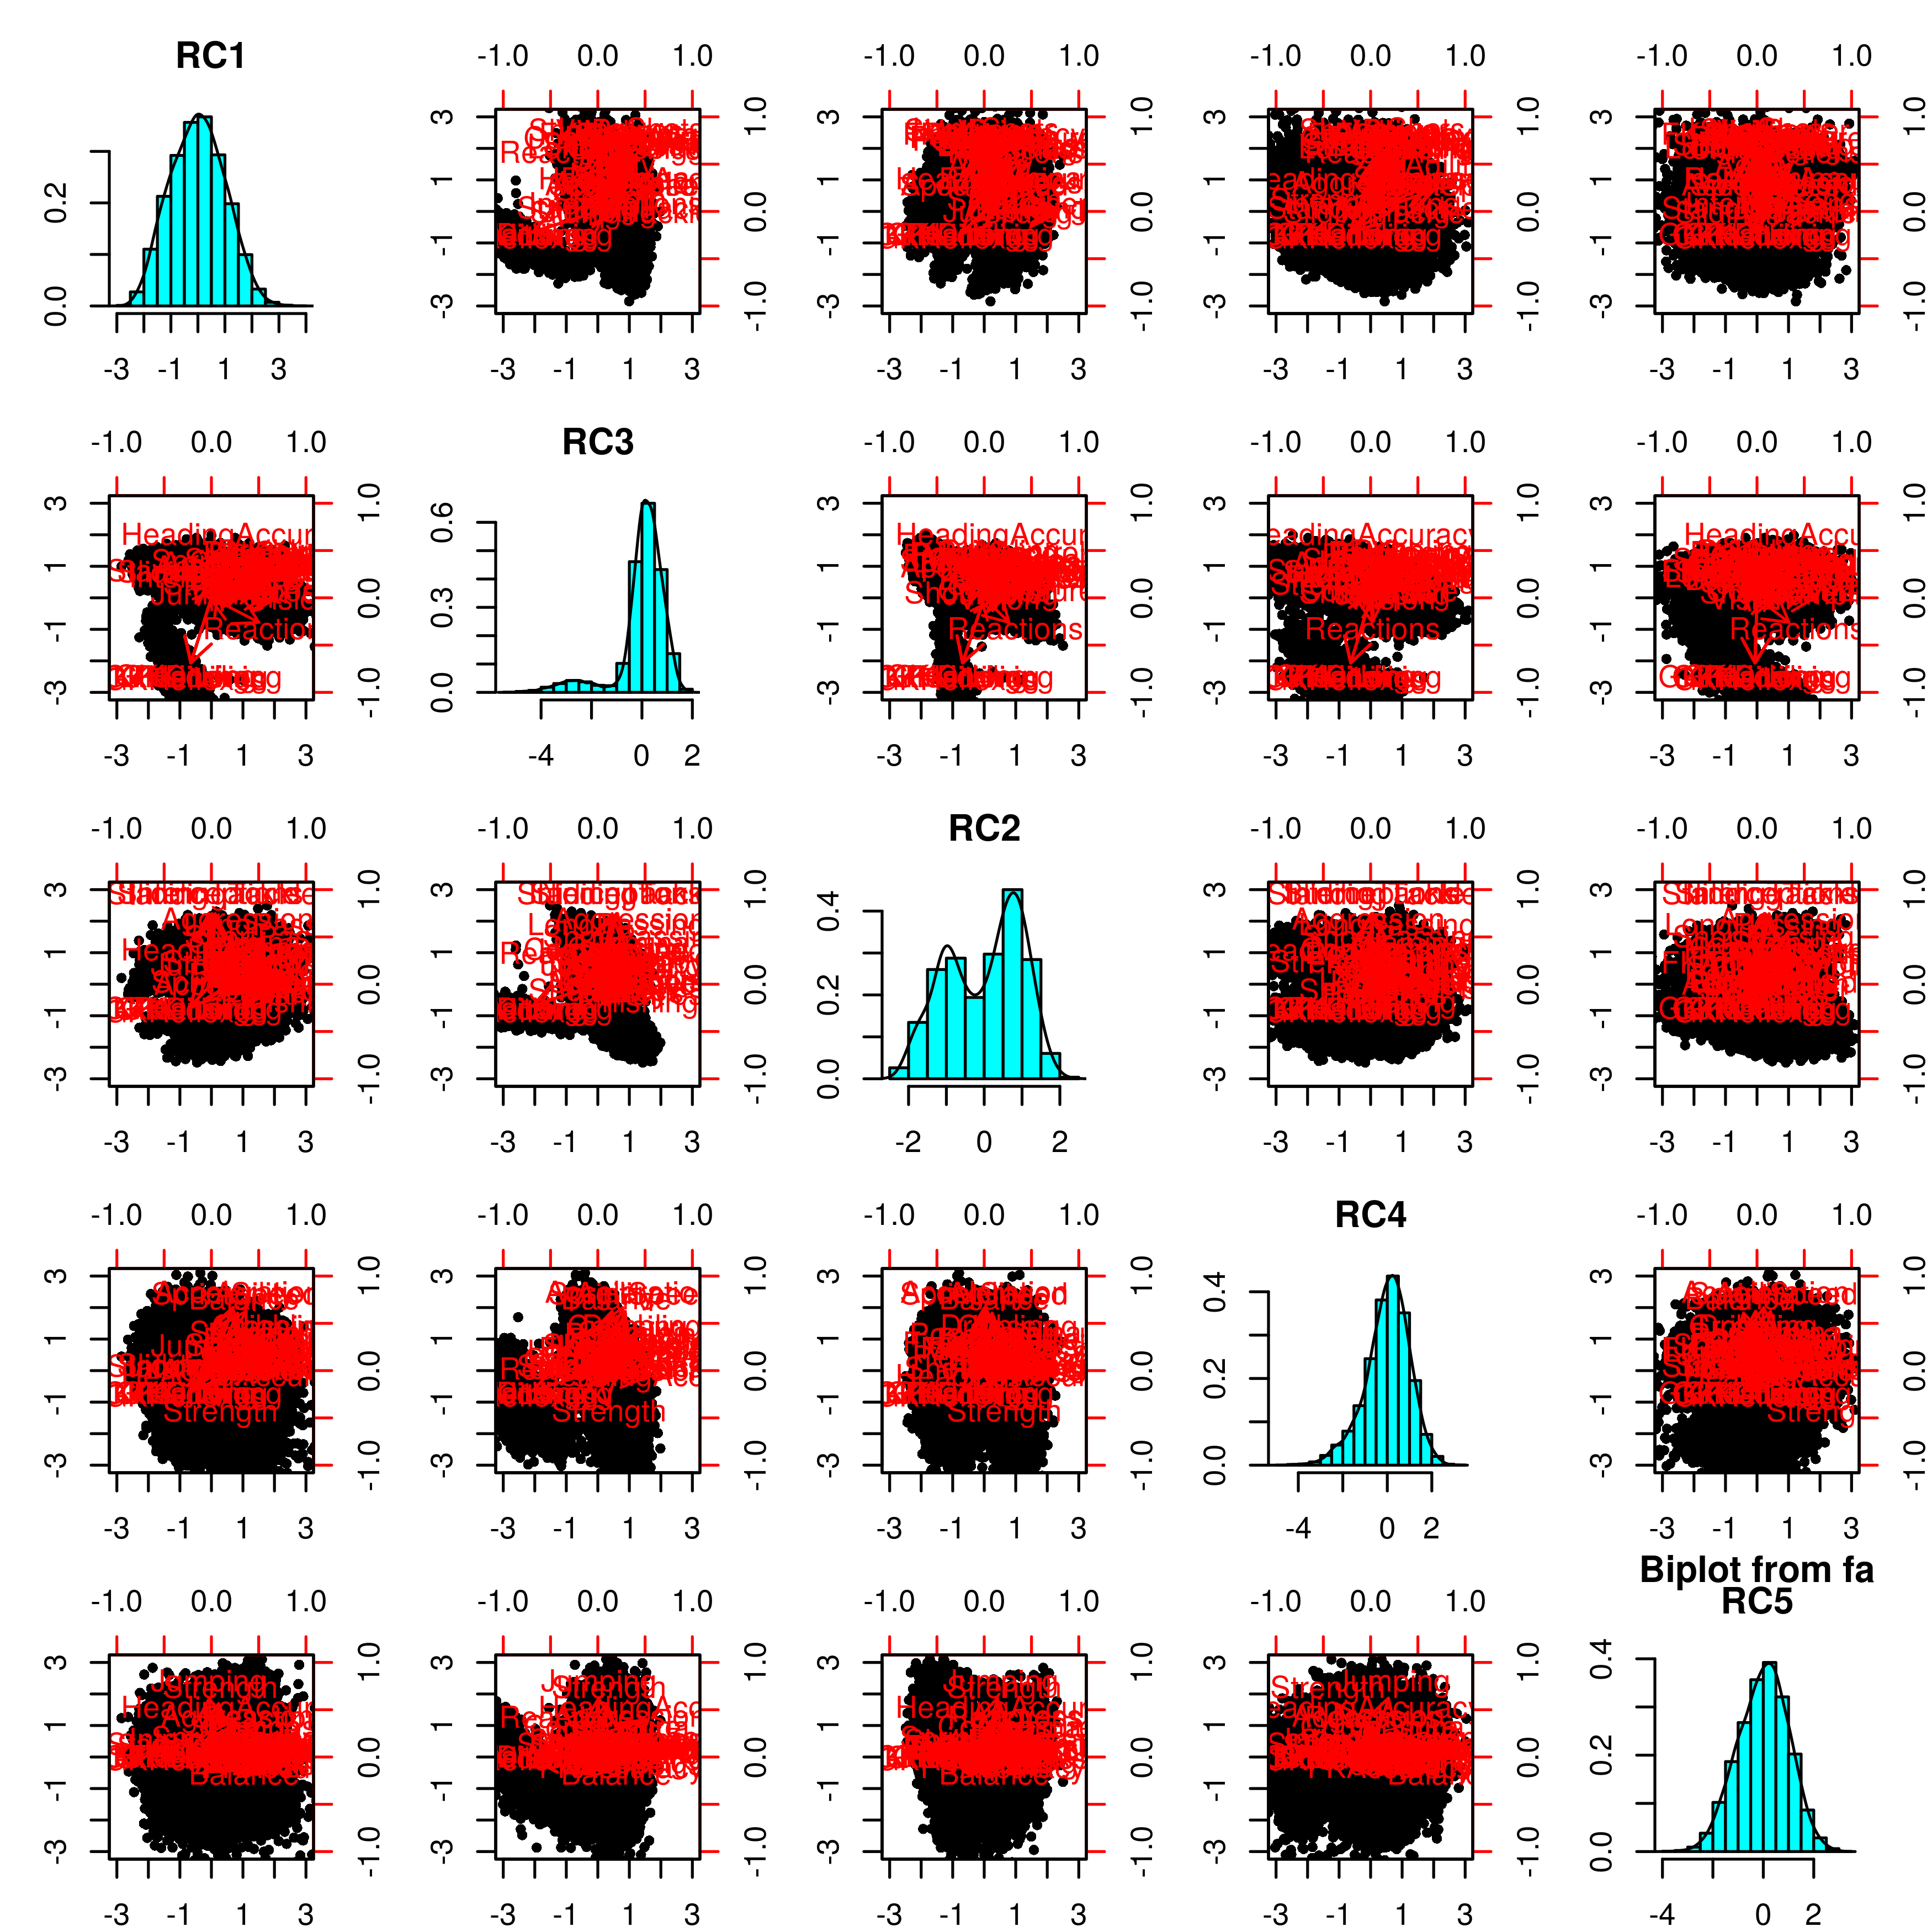

In [20]:
options(repr.plot.res=500)
biplot(fifa_varimax,cex=rep(par("cex"), 0.2))